In [40]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns



In [41]:
df = pd.read_csv("ott_viewer_dropoff_retention_us_v1.0.csv")


In [42]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   show_id               33171 non-null  int64  
 1   title                 33171 non-null  object 
 2   platform              33171 non-null  object 
 3   genre                 33171 non-null  object 
 4   release_year          33171 non-null  float64
 5   season_number         33171 non-null  int64  
 6   episode_number        33171 non-null  int64  
 7   episode_duration_min  33171 non-null  int64  
 8   pacing_score          33171 non-null  int64  
 9   hook_strength         33171 non-null  int64  
 10  dialogue_density      33171 non-null  object 
 11  visual_intensity      33171 non-null  int64  
 12  avg_watch_percentage  33171 non-null  int64  
 13  pause_count           33171 non-null  int64  
 14  rewind_count          33171 non-null  int64  
 15  skip_intro         

In [43]:
if df['skip_intro'].dtype == 'object':
    df['skip_intro'] = df['skip_intro'].str.strip().str.lower()
    df['skip_intro'] = df['skip_intro'].map({'yes': 1, 'no': 0})



In [44]:
df['skip_intro'].dtype
df['skip_intro'].unique()


array([0, 1], dtype=int64)

In [45]:
df['attention_required'] = df['attention_required'].str.strip().str.lower()

attention_map = {
    'low': 1,
    'medium': 2,
    'high': 3
}

df['attention_required'] = df['attention_required'].map(attention_map)


In [46]:
df['attention_required'].unique()
df['attention_required'].dtype


dtype('int64')

In [47]:
if df['cognitive_load'].dtype == 'object':
    df['cognitive_load'] = df['cognitive_load'].str.strip().str.lower()
    df['cognitive_load'] = df['cognitive_load'].map(attention_map)


In [48]:
df[['attention_required', 'cognitive_load']].isna().sum()


attention_required    0
cognitive_load        0
dtype: int64

In [49]:
features = [
    'episode_duration_min',
    'pause_count',
    'rewind_count',
    'skip_intro',
    'pacing_score',
    'hook_strength',
    'cognitive_load',
    'attention_required',
    'season_number'
]

X = df[features]


In [50]:
X.dtypes


episode_duration_min    int64
pause_count             int64
rewind_count            int64
skip_intro              int64
pacing_score            int64
hook_strength           int64
cognitive_load          int64
attention_required      int64
season_number           int64
dtype: object

In [51]:
y_dropoff = df['drop_off']
y_retention = df['retention_risk']


In [52]:
le = LabelEncoder()
y_retention_encoded = le.fit_transform(y_retention)


In [53]:
X_train, X_test, y_train_drop, y_test_drop = train_test_split(
    X, y_dropoff,
    test_size=0.2,
    random_state=42,
    stratify=y_dropoff
)

X_train_r, X_test_r, y_train_ret, y_test_ret = train_test_split(
    X, y_retention_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_retention_encoded
)


In [54]:
scaler_drop = StandardScaler()
X_train = scaler_drop.fit_transform(X_train)
X_test = scaler_drop.transform(X_test)

scaler_ret = StandardScaler()
X_train_r = scaler_ret.fit_transform(X_train_r)
X_test_r = scaler_ret.transform(X_test_r)


Model Name           | Mean Accuracy   | Std Dev        
-------------------------------------------------------
Logistic Reg.        | 0.9590           | 0.0016
Decision Tree        | 0.9436           | 0.0018
Random Forest        | 0.9504           | 0.0010
SVM                  | 0.9579           | 0.0021
KNN                  | 0.9510           | 0.0006
Naive Bayes          | 0.6379           | 0.0060
Gradient Boosting    | 0.9591           | 0.0021
XGBoost              | 0.9558           | 0.0013


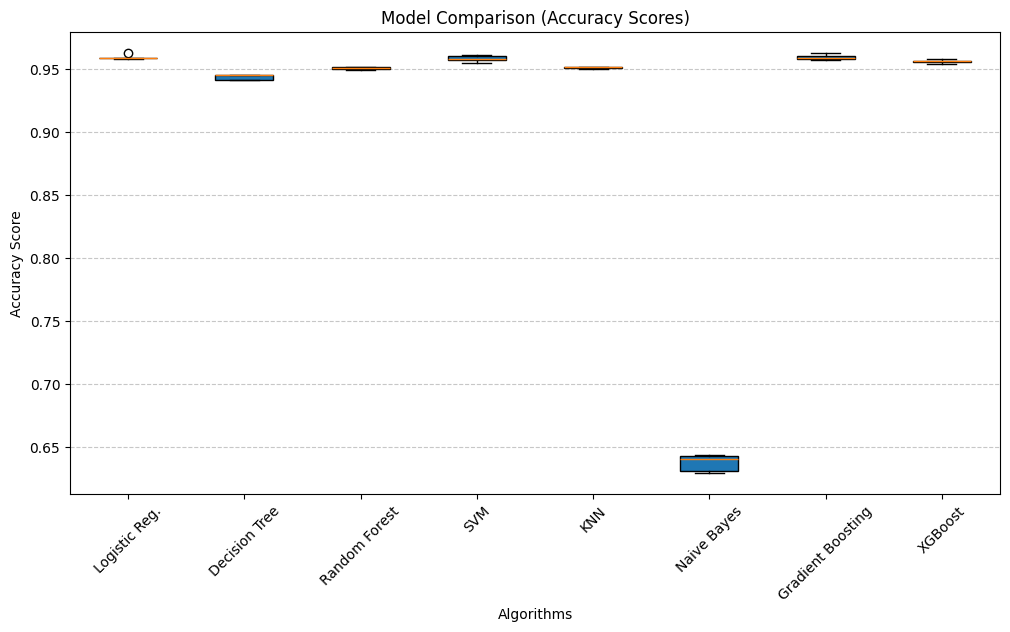

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier


from sklearn.model_selection import cross_val_score, StratifiedKFold

models = []
models.append(('Logistic Reg.', LogisticRegression(max_iter=1000, random_state=42)))
models.append(('Decision Tree', DecisionTreeClassifier(random_state=42)))
models.append(('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)))
models.append(('SVM', SVC(random_state=42)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('Naive Bayes', GaussianNB()))
models.append(('Gradient Boosting', GradientBoostingClassifier(random_state=42)))
models.append(('XGBoost', XGBClassifier(eval_metric='logloss', random_state=42)))

results = []
names = []

print(f"{'Model Name':<20} | {'Mean Accuracy':<15} | {'Std Dev':<15}")
print("-" * 55)

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
 
    cv_results = cross_val_score(model, X_train, y_train_drop, cv=kfold, scoring='accuracy')
    
    results.append(cv_results)
    names.append(name)
    
    print(f"{name:<20} | {cv_results.mean():.4f}           | {cv_results.std():.4f}")


plt.figure(figsize=(12, 6))


plt.boxplot(results, tick_labels=names, patch_artist=True)

plt.title('Model Comparison (Accuracy Scores)')
plt.ylabel('Accuracy Score')
plt.xlabel('Algorithms')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


param_grid = [
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga']
    },
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear', 'newton-cg']
    }
]

lr_base = LogisticRegression(max_iter=2000, random_state=42)

grid_search_lr = GridSearchCV(
    estimator=lr_base, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

print("Starting Hyperparameter Tuning for Logistic Regression...")
grid_search_lr.fit(X_train, y_train_drop)

print("-" * 40)
print(f"Best Parameters Found: {grid_search_lr.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_lr.best_score_:.4f}")
print("-" * 40)

best_lr_model = grid_search_lr.best_estimator_

print("\nEvaluating the Best Model on Test Data:")
y_pred_tuned = best_lr_model.predict(X_test)

print(classification_report(y_test_drop, y_pred_tuned))

Starting Hyperparameter Tuning for Logistic Regression...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
----------------------------------------
Best Parameters Found: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
Best Cross-Validation Accuracy: 0.9595
----------------------------------------

Evaluating the Best Model on Test Data:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      5674
           1       0.90      0.84      0.87       961

    accuracy                           0.96      6635
   macro avg       0.93      0.91      0.92      6635
weighted avg       0.96      0.96      0.96      6635



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

grid_search_xgb = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid_xgb, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

print("Starting Hyperparameter Tuning for XGBoost (Drop-off)...")

grid_search_xgb.fit(X_train, y_train_drop)

print("-" * 40)
print(f"Best Parameters Found: {grid_search_xgb.best_params_}")
print(f"Best CV F1 Score: {grid_search_xgb.best_score_:.4f}")
print("-" * 40)

best_xgb_model = grid_search_xgb.best_estimator_

print("\nEvaluating the Best XGBoost Model on Test Data:")
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

print(classification_report(y_test_drop, y_pred_xgb_tuned))


Starting Hyperparameter Tuning for XGBoost (Drop-off)...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
----------------------------------------
Best Parameters Found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best CV F1 Score: 0.8594
----------------------------------------

Evaluating the Best XGBoost Model on Test Data:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      5674
           1       0.89      0.85      0.87       961

    accuracy                           0.96      6635
   macro avg       0.93      0.92      0.92      6635
weighted avg       0.96      0.96      0.96      6635



Feature Importance Table:
------------------------------
                Feature  Importance
6        cognitive_load    0.348908
4          pacing_score    0.319081
3            skip_intro    0.149204
5         hook_strength    0.129089
1           pause_count    0.046652
0  episode_duration_min    0.003702
2          rewind_count    0.003363
7    attention_required    0.000000
8         season_number    0.000000


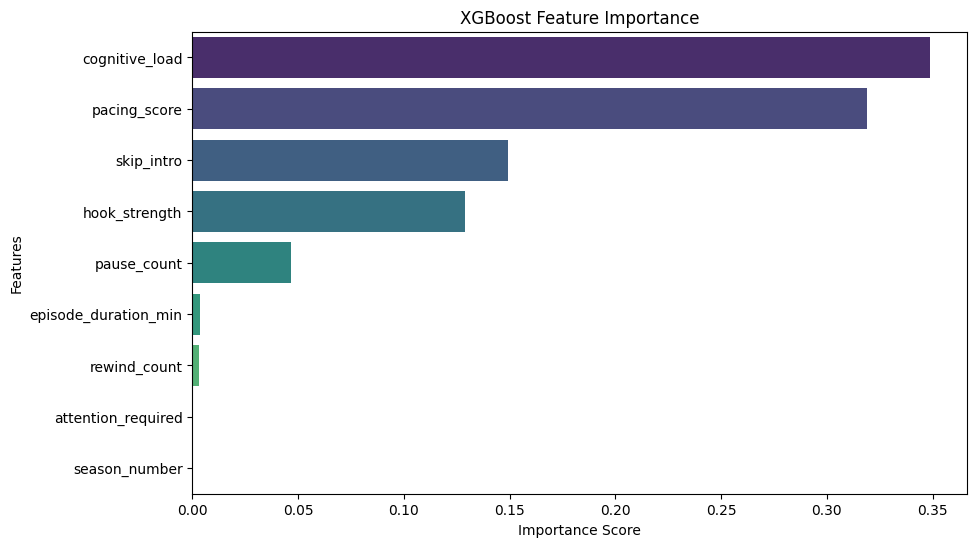

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = xgb_drop.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importance Table:")
print("-" * 30)
print(feature_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature', 
    data=feature_importance, 
    palette='viridis', 
    legend=False       r
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


Model Name           | Mean F1-Weighted   | Std Dev        
----------------------------------------------------------
Logistic Reg.        | 0.9383             | 0.0020
Decision Tree        | 0.9136             | 0.0027
Random Forest        | 0.9256             | 0.0025
SVM                  | 0.9349             | 0.0017
KNN                  | 0.9264             | 0.0017
Naive Bayes          | 0.4466             | 0.0052
Gradient Boosting    | 0.9391             | 0.0020
XGBoost              | 0.9339             | 0.0025


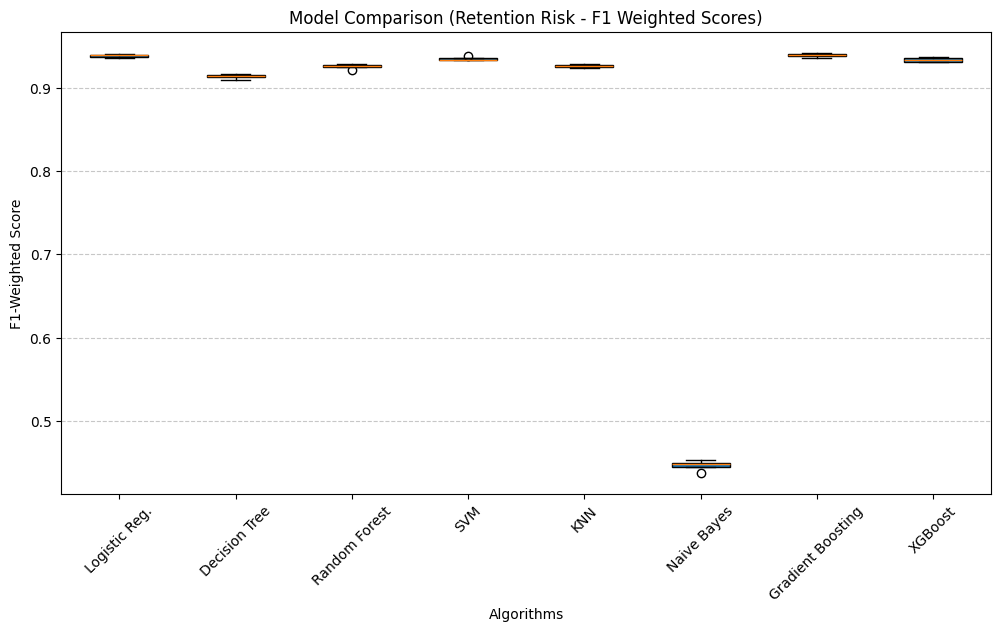

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, StratifiedKFold

models = []
models.append(('Logistic Reg.', LogisticRegression(max_iter=1000, random_state=42)))
models.append(('Decision Tree', DecisionTreeClassifier(random_state=42)))
models.append(('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)))
models.append(('SVM', SVC(random_state=42)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('Naive Bayes', GaussianNB()))
models.append(('Gradient Boosting', GradientBoostingClassifier(random_state=42)))
models.append(('XGBoost', XGBClassifier(eval_metric='mlogloss', random_state=42)))

results = []
names = []

# Print Header
print(f"{'Model Name':<20} | {'Mean F1-Weighted':<18} | {'Std Dev':<15}")
print("-" * 58)

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_results = cross_val_score(model, X_train_r, y_train_ret, cv=kfold, scoring='f1_weighted')
    
    results.append(cv_results)
    names.append(name)
    
    print(f"{name:<20} | {cv_results.mean():.4f}             | {cv_results.std():.4f}")

plt.figure(figsize=(12, 6))

plt.boxplot(results, tick_labels=names, patch_artist=True)

plt.title('Model Comparison (Retention Risk - F1 Weighted Scores)')
plt.ylabel('F1-Weighted Score')
plt.xlabel('Algorithms')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, PrecisionRecallDisplay
import matplotlib.pyplot as plt

param_grid = [
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'] 
    },
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'saga']
    }
]

lr_base_ret = LogisticRegression(
    max_iter=5000, 
    random_state=42, 
    class_weight='balanced'
)

grid_search_ret = GridSearchCV(
    estimator=lr_base_ret, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_weighted',
    n_jobs=-1, 
    verbose=1
)

print("Starting Hyperparameter Tuning for Retention Risk (Low/Medium/High)...")

grid_search_ret.fit(X_train_r, y_train_ret)

print("-" * 50)
print(f"Best Parameters Found: {grid_search_ret.best_params_}")
print(f"Best Cross-Validation F1-Weighted Score: {grid_search_ret.best_score_:.4f}")
print("-" * 50)

best_lr_ret_model = grid_search_ret.best_estimator_

print("\n--- Logistic Regression (Tuned & Balanced) Report ---")
y_pred_ret_tuned = best_lr_ret_model.predict(X_test_r)

print(classification_report(
    y_test_ret, 
    y_pred_ret_tuned, 
    target_names=le.classes_
))

low_class_index = 1 
y_test_binary = (y_test_ret == low_class_index).astype(int)
y_score_low = best_lr_ret_model.predict_proba(X_test_r)[:, low_class_index]


Starting Hyperparameter Tuning for Retention Risk (Low/Medium/High)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
--------------------------------------------------
Best Parameters Found: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation F1-Weighted Score: 0.8942
--------------------------------------------------

--- Logistic Regression (Tuned & Balanced) Report ---
              precision    recall  f1-score   support

        high       0.73      0.96      0.83       961
         low       0.33      0.98      0.49       193
      medium       0.99      0.86      0.92      5481

    accuracy                           0.88      6635
   macro avg       0.68      0.94      0.75      6635
weighted avg       0.93      0.88      0.90      6635



In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

weight_map = {0: 5, 1: 8, 2: 1}
custom_weights = [weight_map[label] for label in y_train_ret]

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_base = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    max_delta_step=1, 
    random_state=42
)

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1_weighted', 
    n_jobs=-1,
    verbose=1
)

print("Starting Hyperparameter Tuning for XGBoost (Retention Risk)...")
grid_search_xgb.fit(X_train_r, y_train_ret, sample_weight=custom_weights)

best_params = grid_search_xgb.best_params_
print("-" * 40)
print(f"Best Parameters Found: {best_params}")
print("-" * 40)

xgb_opt = XGBClassifier(
    **best_params,             
    objective='multi:softprob',
    eval_metric='mlogloss',
    max_delta_step=1,          
    random_state=42
)
print("Training Final Optimized Model...")
xgb_opt.fit(X_train_r, y_train_ret, sample_weight=custom_weights)

y_pred_proba = xgb_opt.predict_proba(X_test_r)

best_threshold = 0.5
best_f1 = 0
low_class_index = 1 

for t in np.arange(0.1, 0.99, 0.01):
    temp_preds = []
    for probs in y_pred_proba:
        if probs[low_class_index] > t:
            temp_preds.append(low_class_index)
        else:
            probs_no_low = probs.copy()
            probs_no_low[low_class_index] = -1
            temp_preds.append(np.argmax(probs_no_low))
    
    f1 = f1_score(
        (y_test_ret == low_class_index).astype(int), 
        (np.array(temp_preds) == low_class_index).astype(int)
    )
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("-" * 40)
print(f"Threshold yielding the Highest Low-Class F1 Score ({best_f1:.2f}): {best_threshold:.2f}")
print("-" * 40)

final_preds = []
for probs in y_pred_proba:
    if probs[low_class_index] > best_threshold:
        final_preds.append(low_class_index)
    else:
        probs_no_low = probs.copy()
        probs_no_low[low_class_index] = -1
        final_preds.append(np.argmax(probs_no_low))

print("\nFinal XGBoost Report (Tuned Parameters + Optimized Threshold):")
print(classification_report(y_test_ret, final_preds, target_names=le.classes_))

Starting Hyperparameter Tuning for XGBoost (Retention Risk)...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
----------------------------------------
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
----------------------------------------
Training Final Optimized Model...
----------------------------------------
Threshold yielding the Highest Low-Class F1 Score (0.63): 0.80
----------------------------------------

Final XGBoost Report (Tuned Parameters + Optimized Threshold):
              precision    recall  f1-score   support

        high       0.72      0.96      0.82       961
         low       0.64      0.62      0.63       193
      medium       0.98      0.92      0.95      5481

    accuracy                           0.92      6635
   macro avg       0.78      0.83      0.80      6635
weighted avg       0.93      0.92      0.92      6635



Training XGBoost (Retention Risk)...

Retention Risk - Feature Importance Table:
---------------------------------------------
                Feature  Importance
6        cognitive_load    0.635293
5         hook_strength    0.138990
3            skip_intro    0.097124
4          pacing_score    0.075901
1           pause_count    0.040342
2          rewind_count    0.006266
0  episode_duration_min    0.006083
7    attention_required    0.000000
8         season_number    0.000000


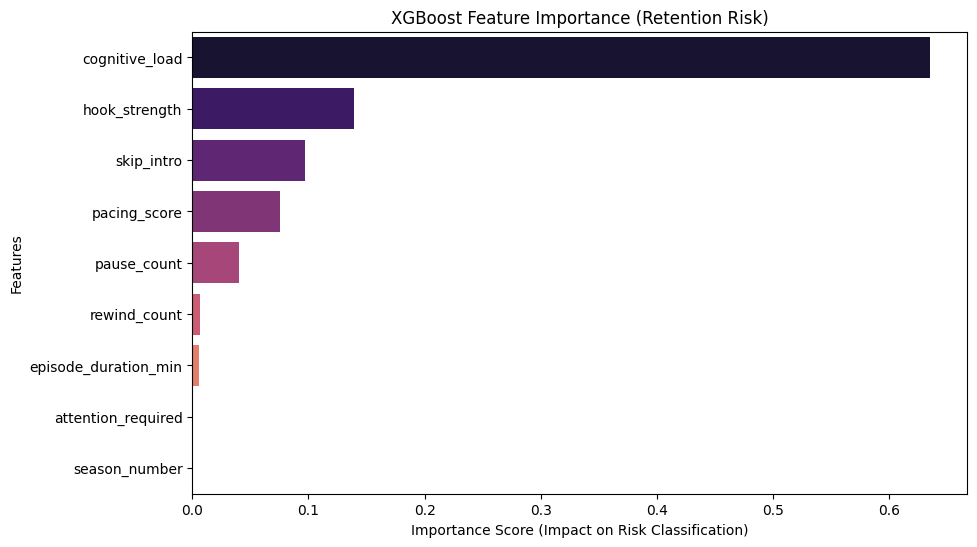

In [ ]:
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

xgb_ret = XGBClassifier(
    n_estimators=200,         
    max_depth=6,               
    learning_rate=0.1,          
    objective='multi:softprob', 
    eval_metric='mlogloss',   
    random_state=42
)

print("Training XGBoost (Retention Risk)...")
xgb_ret.fit(X_train_r, y_train_ret)

importances_ret = xgb_ret.feature_importances_

feature_importance_ret = pd.DataFrame({
    'Feature': features,
    'Importance': importances_ret
}).sort_values(by='Importance', ascending=False)

print("\nRetention Risk - Feature Importance Table:")
print("-" * 45)
print(feature_importance_ret)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature',      
    data=feature_importance_ret, 
    palette='magma',     
    legend=False
)

plt.title('XGBoost Feature Importance (Retention Risk)')
plt.xlabel('Importance Score (Impact on Risk Classification)')
plt.ylabel('Features')
plt.show()

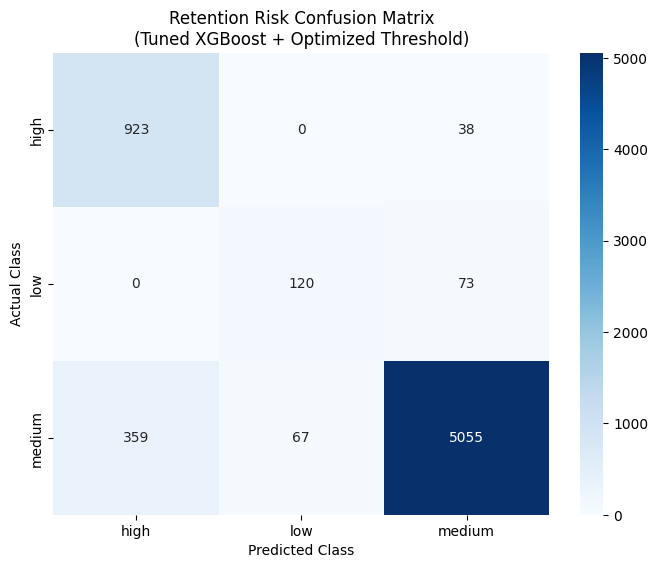

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_ret, final_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',                
    cmap='Blues',           
    xticklabels=le.classes_, 
    yticklabels=le.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Retention Risk Confusion Matrix\n(Tuned XGBoost + Optimized Threshold)")
plt.show()
